<div dir="rtl" style="text-align:right">

# 🚢 یادگیری ماشین و دسته‌بندی با تایتانیک

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/SharifiZarchi/IntroAI/blob/main/Session_06/Titanic_2/Titanic_Classification_Tutorial_2_FA.ipynb) [![Open in Kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://kaggle.com/kernels/welcome?src=https%3A%2F%2Fgithub.com%2FSharifiZarchi%2FIntroAI%2Fblob%2Fmain%2FSession_06%2FTitanic_2%2FTitanic_Classification_Tutorial_2_FA.ipynb)

شب ۲۶ فروردین ۱۲۹۱ (۱۵ آوریل ۱۹۱۲)، تایتانیک؛ «کشتی غرق‌نشدنی»؛ به کوه یخ خورد. از حدود ۲۲۰۰ مسافر و خدمه، بیش از ۱۵۰۰ نفر جان باختند. قایق نجات برای همه نبود… پس **چه کسی جا گرفت؟**

همین سؤال، معروف‌ترین مسابقه مبتدیان در [Kaggle](https://www.kaggle.com/competitions/titanic) شد: با داشتن اطلاعات هر مسافر (سن، جنسیت، کلاس بلیت و…) پیش‌بینی کن که زنده مانده یا نه. امروز قدم‌به‌قدم همین مسئله را حل می‌کنیم و از یک حدس ساده تا راه‌حلی در حدواندازه صدر جدول بالا می‌رویم.

جلسه قبل یک **عدد** را پیش‌بینی کردیم (قیمت خانه)؛ یعنی **رگرسیون**. امروز یک **دسته** را پیش‌بینی می‌کنیم (زنده ماند / نماند)؛ یعنی **دسته‌بندی**. دستور پخت همان است: خواندن ← نگاه ← تمیزکردن ← نمودار ← مدل ← ارزیابی.

**روش کار:** روی هر سلول خاکستری کلیک کن و `Shift + Enter` بزن. سلول‌ها را به ترتیب از بالا اجرا کن. آخر هر بخش یک تمرین کوچک ✏️ هست؛ اول خودت امتحان کن، بعد راه‌حل را باز کن!

داده از [Kaggle](https://www.kaggle.com/competitions/titanic) است و کنار همین فایل با نام `titanic.csv` ذخیره شده.

</div>

<div dir="rtl" style="text-align:right">

---
# بخش ۱: دست‌گرمی: پیش‌بینی یک دسته

در نوت‌بوک قبلی با متغیر، لیست، حلقه و تابع آشنا شدیم. (اگر پایتون برایت تازه است، اول بخش ۱ نوت‌بوک جلسه ۴ را انجام بده؛ پنج دقیقه بیشتر وقت نمی‌گیرد.)

یک بلوک پایتون هنوز مانده که از قضا بذر ایده اصلی امروز است: `if / else`؛ یعنی **تصمیم‌گرفتن**.

</div>

<div dir="rtl" style="text-align:right">

### ۱.۱ `if / else`: کامپیوتر انتخاب می‌کند
کامپیوتر یک شرط را بررسی می‌کند؛ اگر درست بود یک بلوک را اجرا می‌کند، وگرنه بلوک دیگر را. به `:` و تورفتگی خط‌ها دقت کن.

</div>

In [1]:
age = 8

if age < 18:
    print("کودک")
else:
    print("بزرگسال")

کودک


<div dir="rtl" style="text-align:right">

### ۱.۲ یک دسته‌بند دست‌ساز
**دسته‌بند (Classifier)** چیزی نیست جز تابعی که ویژگی‌ها را می‌گیرد و یک دسته تحویل می‌دهد. این هم یک دسته‌بند تک‌قانونی برای تایتانیک. یادت بماند؛ دوباره به آن برمی‌گردیم.

</div>

In [2]:
def guess_survival(sex):
    if sex == "female":
        return 1     # زنده می‌ماند
    else:
        return 0     # زنده نمی‌ماند

print(guess_survival("female"))
print(guess_survival("male"))

1
0


<div dir="rtl" style="text-align:right">

### ۱.۳ کتابخانه‌ها
همان چهار رفیق جلسه قبل.

</div>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

print("کتابخانه‌ها آماده‌اند ✅")

کتابخانه‌ها آماده‌اند ✅


<div dir="rtl" style="text-align:right">

### ✏️ تمرین ۱
کد زیر را طوری تغییر بده که سه گروه چاپ کند: زیر ۱۳ سال «کودک»، از ۱۳ تا ۱۷ «نوجوان» و از ۱۸ به بالا «بزرگسال». (راهنمایی: `elif` یعنی «وگرنه، اگر…»)

</div>

In [4]:
age = 15

# ✏️ نوبت توست؛ یک elif برای نوجوان‌ها اضافه کن
if age < 13:
    print("کودک")
else:
    print("بزرگسال")

بزرگسال


<div dir="rtl" style="text-align:right">

<details>
<summary>💡 راه‌حل (برای بازشدن کلیک کن)</summary>

<div dir="ltr" style="text-align:left">

```python
age = 15

if age < 13:
    print("کودک")
elif age < 18:
    print("نوجوان")
else:
    print("بزرگسال")
```
</div>

</details>

</div>

<div dir="rtl" style="text-align:right">

---
# بخش ۲: خواندن داده

هر سطر یک مسافر، هر ستون یک قلم اطلاعات.

</div>

In [5]:
# فایل کنار همین نوت‌بوک است؛ اگر پیدا نشد (مثلا در Google Colab)
# همان فایل را مستقیم از گیت‌هاب دوره می‌خوانیم.
url = "https://raw.githubusercontent.com/SharifiZarchi/IntroAI/main/Session_05/Titanic/titanic.csv"
try:
    df = pd.read_csv("titanic.csv")
except FileNotFoundError:
    df = pd.read_csv(url)

print("جدول ما", df.shape[0], "سطر و", df.shape[1], "ستون دارد")

جدول ما 891 سطر و 12 ستون دارد


<div dir="rtl" style="text-align:right">

چند سطر اول را با `.head()` ببینیم:

</div>

In [6]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


<div dir="rtl" style="text-align:right">

معنی هر ستون:

| ستون | معنی |
|---|---|
| `Survived` | **برچسبی که می‌خواهیم پیش‌بینی کنیم**: ۱ = زنده ماند، ۰ = جان باخت |
| `Pclass` | کلاس بلیت: ۱ = درجه‌یک (گران)، ۲ = متوسط، ۳ = درجه‌سه (ارزان) |
| `Name`, `Sex`, `Age` | نام، جنسیت، سن |
| `SibSp` | تعداد خواهر/برادر + همسر همراه در کشتی |
| `Parch` | تعداد والدین + فرزندان همراه در کشتی |
| `Ticket`, `Fare` | شماره بلیت و قیمت بلیت |
| `Cabin` | شماره کابین (اگر ثبت شده باشد) |
| `Embarked` | بندر سوارشدن: S = ساوت‌همپتون، C = شربورگ، Q = کوئینزتاون |

به زبان جلسه ۳: ستون `Survived` **برچسب** است و بقیه ستون‌ها **ویژگی**.

</div>

<div dir="rtl" style="text-align:right">

### ✏️ تمرین ۲
`.head()` سطرهای اول را نشان می‌دهد و `.tail()` سطرهای آخر را. ۵ مسافر آخر جدول را نمایش بده.

</div>

In [7]:
# ✏️ نوبت توست

df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


<div dir="rtl" style="text-align:right">

<details>
<summary>💡 راه‌حل (برای بازشدن کلیک کن)</summary>

<div dir="ltr" style="text-align:left">

```python
df.tail()
```
</div>

</details>

</div>

<div dir="rtl" style="text-align:right">

---
# بخش ۳: نگاه به داده

همان سه فرمان جلسه قبل: `.info()`، `.describe()` و `.value_counts()`.

</div>

<div dir="rtl" style="text-align:right">

### ۳.۱ `.info()`: نوع ستون‌ها و مقدارهای جاافتاده

</div>

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


<div dir="rtl" style="text-align:right">

جدول ۸۹۱ سطر دارد، ولی `Age` فقط ۷۱۴ مقدار؛ یعنی سن ۱۷۷ مسافر نامعلوم است. `Cabin` تقریبا خالی است (۶۸۷ جاافتاده!) و `Embarked` هم ۲ تا کم دارد. داده واقعی هیچ‌وقت کامل نیست؛ در بخش ۵ حلش می‌کنیم.

</div>

<div dir="rtl" style="text-align:right">

### ۳.۲ `.describe()`: خلاصه آماری

</div>

In [9]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


<div dir="rtl" style="text-align:right">

سطر `mean` را بخوان: میانگین `Survived` حدود ۰.۳۸ است؛ یعنی **فقط ۳۸٪ زنده ماندند**. میانگین سن حدود ۳۰ سال است و قیمت بلیت از ۰ تا ۵۱۲ پوند چشمگیر!

</div>

<div dir="rtl" style="text-align:right">

### ۳.۳ `.value_counts()`: شمارش دسته‌ها

</div>

In [10]:
print("زنده ماند؟")
print(df["Survived"].value_counts())

print("\nجنسیت:")
print(df["Sex"].value_counts())

print("\nکلاس بلیت:")
print(df["Pclass"].value_counts())

زنده ماند؟
Survived
0    549
1    342
Name: count, dtype: int64

جنسیت:
Sex
male      577
female    314
Name: count, dtype: int64

کلاس بلیت:
Pclass
3    491
1    216
2    184
Name: count, dtype: int64


<div dir="rtl" style="text-align:right">

۵۴۹ نفر جان باختند و ۳۴۲ نفر زنده ماندند. بیشتر مسافران مرد بودند و بیشترشان درجه‌سه سفر می‌کردند. این عددها را به خاطر بسپار؛ صحنه را می‌چینند.

</div>

<div dir="rtl" style="text-align:right">

### ✏️ تمرین ۳
از هر بندر چند مسافر سوار شدند؟ از `.value_counts()` روی ستون `Embarked` استفاده کن.

</div>

In [12]:
# ✏️ نوبت توست

print(df['Embarked'].value_counts())

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64


<div dir="rtl" style="text-align:right">

<details>
<summary>💡 راه‌حل (برای بازشدن کلیک کن)</summary>

<div dir="ltr" style="text-align:left">

```python
print(df["Embarked"].value_counts())
# ساوت‌همپتون (S) ۶۴۴ نفر، شربورگ (C) ۱۶۸ نفر، کوئینزتاون (Q) ۷۷ نفر
```
</div>

</details>

</div>

<div dir="rtl" style="text-align:right">

---
# بخش ۴: بینش: قبل از مدل، جواب را ببین

این مهم‌ترین بخش نوت‌بوک است. قبل از هر مدلی، از خود داده می‌پرسیم: **چه کسی زنده ماند؟** هر الگویی که این‌جا پیدا کنیم، چیزی است که یک مدل خوب هم باید پیدایش کند؛ پس بعدا می‌توانیم بسنجیم که مدل‌هایمان داده را «فهمیده‌اند» یا نه.

</div>

<div dir="rtl" style="text-align:right">

### ۴.۱ بقا بر حسب جنسیت
`groupby("Sex")` مسافرها را گروه‌بندی می‌کند، و میانگین یک ستون ۰ و ۱ دقیقا همان **نرخ بقا**ست.

</div>

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64


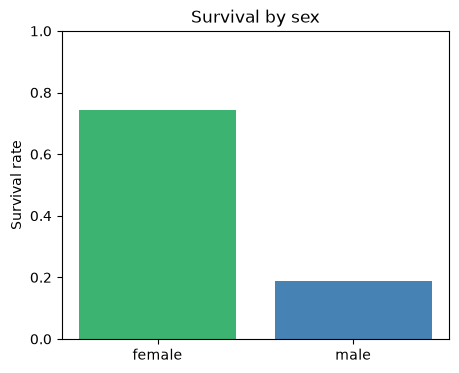

In [13]:
rate_by_sex = df.groupby("Sex")["Survived"].mean()
print(rate_by_sex)

plt.figure(figsize=(5, 4))
plt.bar(["female", "male"], rate_by_sex[["female", "male"]], color=["mediumseagreen", "steelblue"])
plt.ylabel("Survival rate")
plt.title("Survival by sex")
plt.ylim(0, 1)
plt.show()

<div dir="rtl" style="text-align:right">

شکافی عظیم: **۷۴٪ زن‌ها زنده ماندند در برابر ۱۹٪ مردها.** «اول زن‌ها و بچه‌ها» فقط یک جمله نبود؛ بعد از یک قرن، همین‌جا در داده دیده می‌شود. این تک‌واقعیت، قوی‌ترین سیگنال کل این مجموعه‌داده است.

</div>

<div dir="rtl" style="text-align:right">

### ۴.۲ بقا بر حسب کلاس بلیت

</div>

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


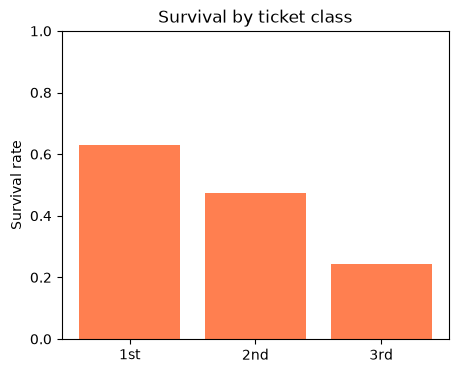

In [14]:
rate_by_class = df.groupby("Pclass")["Survived"].mean()
print(rate_by_class)

plt.figure(figsize=(5, 4))
plt.bar(["1st", "2nd", "3rd"], rate_by_class[[1, 2, 3]], color="coral")
plt.ylabel("Survival rate")
plt.title("Survival by ticket class")
plt.ylim(0, 1)
plt.show()

<div dir="rtl" style="text-align:right">

درجه‌یک ۶۳٪، درجه‌دو ۴۷٪، درجه‌سه ۲۴٪. قایق‌های نجات روی عرشه‌های بالایی بودند، کنار کابین‌های گران. پول مهم بود.

</div>

<div dir="rtl" style="text-align:right">

### ۴.۳ بچه‌ها چه شدند؟
دو هیستوگرام روی هم: سن زنده‌مانده‌ها (سبز) و جان‌باخته‌ها (خاکستری).

</div>

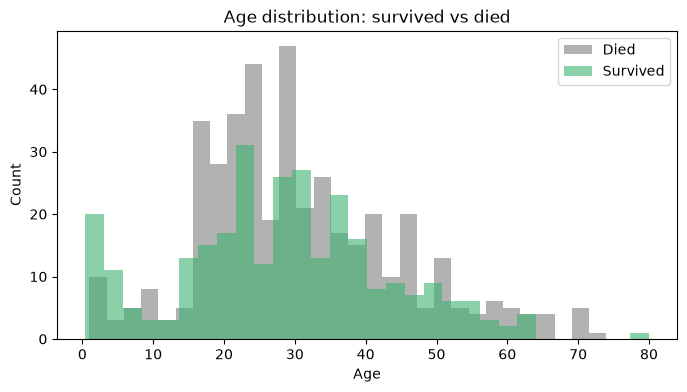

نرخ بقای بچه‌های زیر ۱۰ سال: 0.61
نرخ بقای همه:                0.38


In [15]:
plt.figure(figsize=(8, 4))
plt.hist(df[df["Survived"] == 0]["Age"].dropna(), bins=30, alpha=0.6, color="gray", label="Died")
plt.hist(df[df["Survived"] == 1]["Age"].dropna(), bins=30, alpha=0.6, color="mediumseagreen", label="Survived")
plt.xlabel("Age")
plt.ylabel("Count")
plt.title("Age distribution: survived vs died")
plt.legend()
plt.show()

print("نرخ بقای بچه‌های زیر ۱۰ سال:", round(df[df["Age"] < 10]["Survived"].mean(), 2))
print("نرخ بقای همه:               ", round(df["Survived"].mean(), 2))

<div dir="rtl" style="text-align:right">

به منتهی‌الیه چپ نمودار نگاه کن: برای بچه‌های کوچک، ستون‌های سبز از خاکستری‌ها بلندترند؛ **۶۱٪ بچه‌های زیر ۱۰ سال زنده ماندند**، در برابر ۳۸٪ کل مسافران. بخش «بچه‌ها»ی آن جمله هم تأیید شد.

</div>

<div dir="rtl" style="text-align:right">

### ۴.۴ جنسیت و کلاس، با هم
دو سیگنال قوی در یک تصویر.

</div>

Sex     female  male
Pclass              
1         0.97  0.37
2         0.92  0.16
3         0.50  0.14


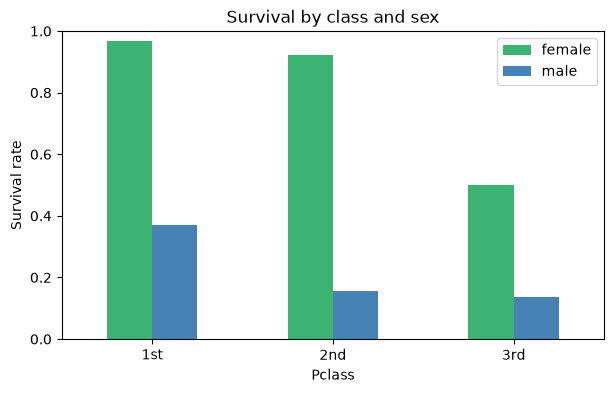

In [16]:
table = df.groupby(["Pclass", "Sex"])["Survived"].mean().unstack()
print(table.round(2))

table.plot(kind="bar", figsize=(7, 4), color=["mediumseagreen", "steelblue"])
plt.ylabel("Survival rate")
plt.title("Survival by class and sex")
plt.xticks([0, 1, 2], ["1st", "2nd", "3rd"], rotation=0)
plt.ylim(0, 1)
plt.legend(["female", "male"])
plt.show()

<div dir="rtl" style="text-align:right">

دو سر طیف تکان‌دهنده است: یک زن درجه‌یک با احتمال **۹۷٪** زنده می‌ماند؛ یک مرد درجه‌سه با **۱۳٪**. تمام قصه تایتانیک؛ و تمام چیزی که مدل‌های ما قرار است یاد بگیرند؛ بین این دو مسافر است.

</div>

<div dir="rtl" style="text-align:right">

### ۴.۵ مسئله دسته‌بندی چه شکلی است؟
یک تصویر آخر، که از نظر مفهومی مهم‌ترین است. هر نقطه یک مسافر است: سن روی یک محور، قیمت بلیت روی محور دیگر. سبز = زنده ماند، خاکستری = جان باخت.

</div>

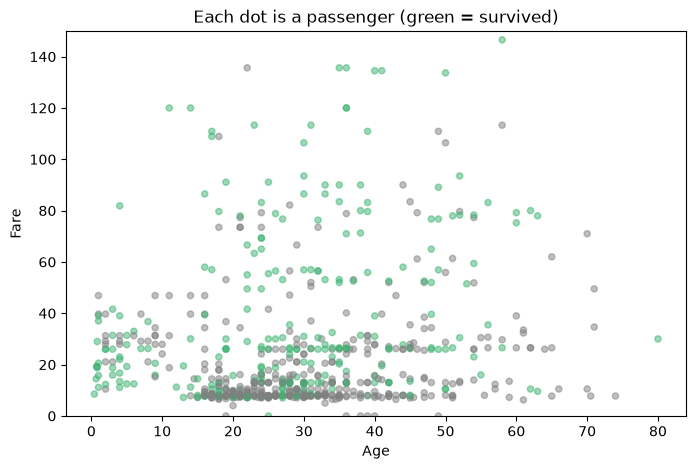

In [17]:
plt.figure(figsize=(8, 5))
colors = df["Survived"].map({0: "gray", 1: "mediumseagreen"})
plt.scatter(df["Age"], df["Fare"], c=colors, alpha=0.5, s=20)
plt.xlabel("Age")
plt.ylabel("Fare")
plt.ylim(0, 150)   # چند بلیت خیلی گران را می‌بریم تا بقیه دیده شوند
plt.title("Each dot is a passenger (green = survived)")
plt.show()

<div dir="rtl" style="text-align:right">

**این تصویر خود دسته‌بندی است.** تمام کار یک دسته‌بند: نقطه جدیدی به تو می‌دهند و باید رنگش را حدس بزنی. گرایش را می‌بینی؛ سبزها دور بلیت‌های گران و سن‌های کم جمع شده‌اند؛ ولی رنگ‌ها قاطی‌اند و هیچ خط راستی نمی‌تواند جدایشان کند. دقیقا برای همین به مدل‌هایی باهوش‌تر از خط‌کش نیاز داریم.

(اسلاید دسته‌بندی موجودات فضایی جلسه ۲ یادت هست؟ همان تصویر است، این بار با داده واقعی.)

</div>

<div dir="rtl" style="text-align:right">

### ✏️ تمرین ۴
نرخ بقا بر حسب بندر سوارشدن (`Embarked`) را مثل نمودار جنسیت، ستونی رسم کن. مسافران کدام بندر خوش‌شانس‌تر بودند؟ حدس می‌زنی چرا؟ (راهنمایی از ۴.۲: به کلاس بلیت فکر کن.)

</div>

Embarked
C    0.553571
Q    0.389610
S    0.336957
Name: Survived, dtype: float64


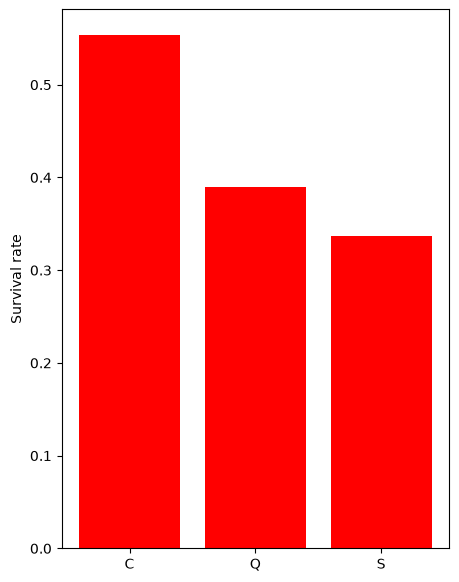

In [18]:
# ✏️ نوبت توست
# rate_by_port = df.groupby(...)[...].mean()
rate_by_port = df.groupby('Embarked')['Survived'].mean()
print(rate_by_port)
plt.figure(figsize=(5,7))
plt.bar(['C','Q','S'],rate_by_port[['C','Q','S']],color='red')
plt.ylabel('Survival rate')
plt.show()


<div dir="rtl" style="text-align:right">

<details>
<summary>💡 راه‌حل (برای بازشدن کلیک کن)</summary>

<div dir="ltr" style="text-align:left">

```python
rate_by_port = df.groupby("Embarked")["Survived"].mean()
print(rate_by_port)

plt.figure(figsize=(5, 4))
plt.bar(["C", "Q", "S"], rate_by_port[["C", "Q", "S"]], color="mediumpurple")
plt.ylabel("Survival rate")
plt.title("Survival by boarding port")
plt.show()
```

</div>

شربورگ (۵۵٪) از کوئینزتاون (۳۹٪) و ساوت‌همپتون (۳۴٪) جلوتر است؛ عمدتا چون بسیاری از مسافران درجه‌یک از شربورگ سوار شدند. خود بندر کسی را نجات نداد؛ این پژواک پنهان کلاس بلیت است!

</details>

</div>

<div dir="rtl" style="text-align:right">

---
# بخش ۵: تمیزکردن و آماده‌سازی

مدل‌ها جدولی از **عددهای بدون حفره** می‌خواهند. ما هم حفره داریم (سن‌های جاافتاده) و هم متن (`Sex` و `Embarked`). سه اصلاح، با همان ابزارهای جلسه قبل.

</div>

<div dir="rtl" style="text-align:right">

### ۵.۱ پرکردن حفره‌ها
- `Age`های جاافتاده ← با میانه سن (۲۸) پر می‌کنیم.
- ۲ مقدار جاافتاده `Embarked` ← با رایج‌ترین بندر (`S`).
- `Cabin` برای ۶۸۷ نفر از ۸۹۱ مسافر جاافتاده؛ حفره‌ها بیش از آن‌اند که صادقانه پرشان کنیم، پس فعلا استفاده‌اش نمی‌کنیم (فعلا… در بخش ۹ برمی‌گردد!).
- یک پانوشت صادقانه: این میانه را از همه ۸۹۱ ردیف و *پیش از* تقسیم حساب می‌کنیم؛ اصولی‌اش این است که فقط از ردیف‌های آموزش بیاید تا چیزی از مجموعه آزمون نشت نکند. (این‌جا هر دو همان ۲۸ را می‌دهند؛ در خط لوله واقعی، پرکننده فقط روی داده آموزش برازش می‌شود.)

</div>


In [19]:
data = df.copy()          # روی یک کپی کار می‌کنیم تا نسخه اصلی سالم بماند

data["Age"] = data["Age"].fillna(data["Age"].median())
data["Embarked"] = data["Embarked"].fillna("S")

print("مقدارهای جاافتاده حالا:")
print(data[["Age", "Embarked"]].isna().sum())

مقدارهای جاافتاده حالا:
Age         0
Embarked    0
dtype: int64


<div dir="rtl" style="text-align:right">

### ۵.۲ تبدیل متن به عدد
- `Sex` ← یک ستون ۰ و ۱ جدید به نام `Female` (این ترفند برای هر ستون دودسته‌ای جواب می‌دهد).
- `Embarked` سه دسته دارد ← وان‌هات با `get_dummies`، دقیقا مثل محله‌های جلسه قبل.

</div>

In [20]:
data["Female"] = (data["Sex"] == "female").astype(int)
data = pd.get_dummies(data, columns=["Embarked"], prefix="Port")

data[["Name", "Sex", "Female", "Port_C", "Port_Q", "Port_S"]].head()

,Name,Sex,Female,Port_C,Port_Q,Port_S
0,"Braund, Mr. Owen Harris",male,0,False,False,True
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,1,True,False,False
2,"Heikkinen, Miss. Laina",female,1,False,False,True
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,1,False,False,True
4,"Allen, Mr. William Henry",male,0,False,False,True


<div dir="rtl" style="text-align:right">

### ۵.۳ ویژگی‌ها، برچسب و تقسیم آموزش/آزمون
همان آیین همیشگی: مدل روی بخش آموزش یاد می‌گیرد و روی بخش آزمونی که هرگز ندیده نمره می‌گیرد.

</div>

In [21]:
FEATURES = ["Pclass", "Female", "Age", "SibSp", "Parch", "Fare",
            "Port_C", "Port_Q", "Port_S"]

X = data[FEATURES]        # ویژگی‌ها (ورودی)
y = data["Survived"]      # برچسب (چیزی که پیش‌بینی می‌کنیم)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42   # ۲۰٪ برای آزمون
)

print("آموزش:", len(X_train), " آزمون:", len(X_test))

آموزش: 712  آزمون: 179


<div dir="rtl" style="text-align:right">

### ✏️ تمرین ۵
مطمئن شو ویژگی‌هایمان واقعا دیگر حفره ندارند: تعداد مقدارهای جاافتاده هر ستون `X` را چاپ کن. (راهنمایی: `.isna().sum()`)

</div>

In [22]:
# ✏️ نوبت توست

print(X.isna().sum())

Pclass    0
Female    0
Age       0
SibSp     0
Parch     0
Fare      0
Port_C    0
Port_Q    0
Port_S    0
dtype: int64


<div dir="rtl" style="text-align:right">

<details>
<summary>💡 راه‌حل (برای بازشدن کلیک کن)</summary>

<div dir="ltr" style="text-align:left">

```python
print(X.isna().sum())
# همه عددها باید صفر باشند
```

</div>
</details>

</div>

<div dir="rtl" style="text-align:right">

---
# بخش ۶: اولین مدل‌ها: از حدس کور تا درخت تصمیم

نمره یک دسته‌بند را چطور بدهیم؟ با **دقت (Accuracy)**: سهم مسافرهایی که برچسبشان را درست می‌زند. ۱ یعنی بی‌نقص، و… بگذار ببینیم «هیچ تلاشی» چند می‌گیرد.

</div>

<div dir="rtl" style="text-align:right">

### ۶.۱ تنبل‌ترین مدل دنیا
به همه، هر که باشند، می‌گوید «جان باخت». ابلهانه به نظر می‌رسد؛ ولی چون بیشتر مسافران واقعا جان باختند، بیشتر وقت‌ها درست می‌گوید! نمره همه مدل‌ها را در دیکشنری `results` جمع می‌کنیم.

</div>

In [23]:
from sklearn.metrics import accuracy_score

pred_lazy = np.zeros(len(y_test))          # برای همه: ۰ = «جان باخت»
acc = accuracy_score(y_test, pred_lazy)

results = {}                               # جدول امتیازهای کل جلسه
results["Always 'died'"] = acc
print("دقت:", round(acc, 3))

دقت: 0.587


In [ ]:
from sklearn.metrics import accuracy_score
pred_lazy=np.zeros(len(y_test))
acc=accuracy_score(y_test,pred_lazy)
results={}
results['Always \'died\'']=acc
print('accuracy:',round(acc, 3))
#code by me

<div dir="rtl" style="text-align:right">

**۵۹٪ بدون این‌که چیزی بداند!** به این می‌گویند **خط پایه (Baseline)** و درسی حیاتی می‌دهد: تا ندانی حدس کور چند می‌گیرد، هیچ عدد دقتی نباید تحت‌تأثیرت قرار دهد. مدلی با «دقت ۹۰٪» برای بیماری‌ای که ۹۵٪ مردم ندارند، از هیچ‌کاری‌نکردن هم *بدتر* است.

</div>

<div dir="rtl" style="text-align:right">

### ۶.۲ یک قانون بهتر از هیچ قانون
حالا دسته‌بند دست‌سازمان از بخش ۱: زن‌ها زنده می‌مانند، مردها نه. یک `if`، بر اساس قوی‌ترین الگوی بخش ۴.

</div>

In [24]:
pred_one_rule = X_test["Female"]           # برای زن‌ها ۱، برای مردها ۰؛ دقیقا همان پیش‌بینی ما
acc = accuracy_score(y_test, pred_one_rule)

results["One rule: sex"] = acc
print("دقت:", round(acc, 3))

دقت: 0.782


In [25]:
print(results)

{"Always 'died'": 0.5865921787709497, 'One rule: sex': 0.7821229050279329}


<div dir="rtl" style="text-align:right">

**۷۸٪ با یک if!** این جهش؛ از ۵۹ به ۷۸؛ تماما از *بینش* آمد، نه از ماشین‌آلات. ولی درآوردن چند درصد بعدی با دست (قانون برای کلاس؟ سن؟ ترکیب‌ها؟) خیلی زود آشفته می‌شود. وقتش است بگذاریم ماشین خودش قانون‌ها را بنویسد.

</div>

<div dir="rtl" style="text-align:right">

### ۶.۳ درخت تصمیم: ماشینی که «بیست سؤالی» یاد می‌گیرد
**درخت تصمیم (Decision Tree)** درباره ویژگی‌ها سؤال‌های بله/خیر می‌پرسد، یکی پس از دیگری، و هر جواب به سؤال بعدی می‌رسد؛ درختی از `if / else`ها. جادوی *یادگیری* این‌جاست: ماشین خودش از داده آموزش کشف می‌کند که **چه سؤال‌هایی و به چه ترتیبی بپرسد** (سؤالی را انتخاب می‌کند که زنده‌مانده‌ها را از جان‌باخته‌ها بهتر جدا کند، و در هر شاخه همین کار را تکرار می‌کند).

`max_depth=3` یعنی: برای هر مسافر حداکثر ۳ سؤال.

</div>

In [30]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(max_depth=3, random_state=42)
tree.fit(X_train, y_train)                 # یادگیری این‌جا اتفاق می‌افتد

acc = tree.score(X_test, y_test)           # score. یعنی پیش‌بینی + دقت، یک‌جا
results["Decision tree"] = acc
print("دقت:", round(acc, 3))

دقت: 0.799


<div dir="rtl" style="text-align:right">

### ۶.۴ شیوه‌ی فکر کردن درخت را ببین 🌳
برخلاف بیشتر مدل‌ها، درخت می‌تواند دقیقا نشانمان بدهد چطور فکر می‌کند.

</div>

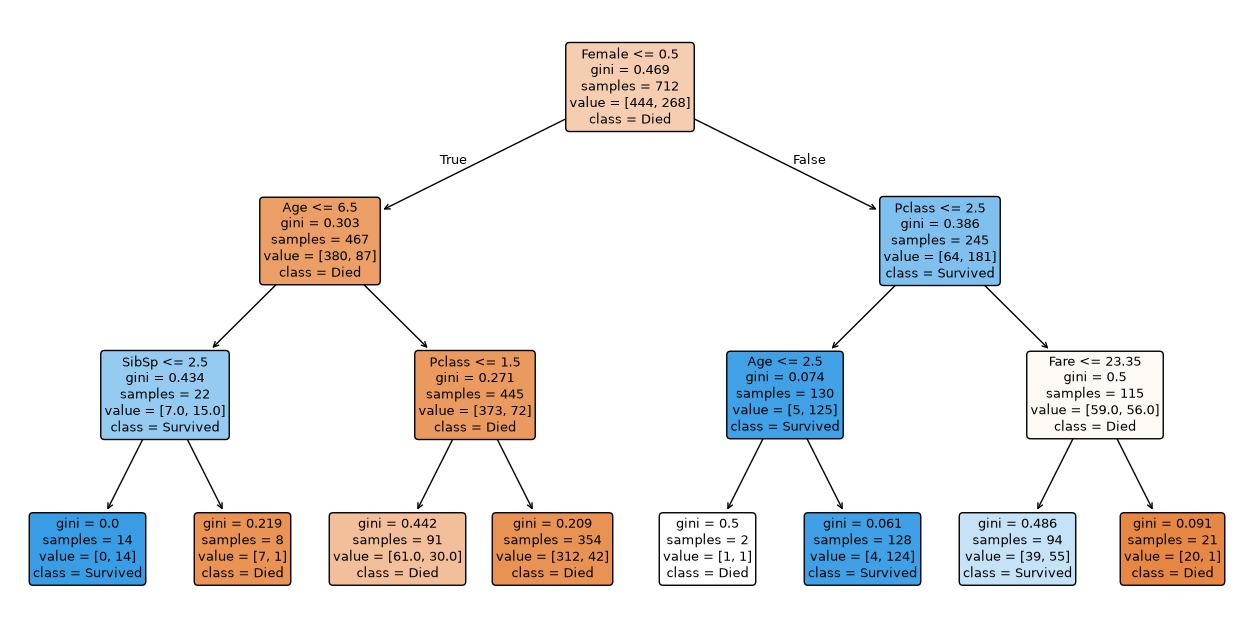

In [31]:
from sklearn.tree import plot_tree

plt.figure(figsize=(16, 8))
plot_tree(tree, feature_names=FEATURES, class_names=["Died", "Survived"],
          filled=True, rounded=True, fontsize=9)
plt.show()

<div dir="rtl" style="text-align:right">

جعبه بالایی را بخوان: اولین سؤال درخت **«Female ≤ 0.5؟»** است؛ یعنی این مسافر مرد است؟ درخت قانون دست‌ساز ما را *خودش* دوباره کشف کرد و بعد دقیق‌ترش کرد: برای مردها سراغ سن می‌رود (پسربچه‌ها شانسی دارند)، برای زن‌ها سراغ کلاس و قیمت بلیت. جعبه‌های نارنجی به «جان باخت» متمایل‌اند و آبی‌ها به «زنده ماند».

هر الگویی که در نمودارهای بخش ۴ دیدیم؛ جنسیت، کلاس، بچه‌ها؛ این‌جاست، خودکار پیدا شده. **مدل با چشم‌های ما هم‌نظر است.**

</div>

<div dir="rtl" style="text-align:right">

### ۶.۵ هرچه عمیق‌تر، بهتر… نه؟
سؤال بیشتر = دقت بیشتر، لابد. عمق را زیاد کنیم و هر دو نمره را تماشا کنیم.

</div>

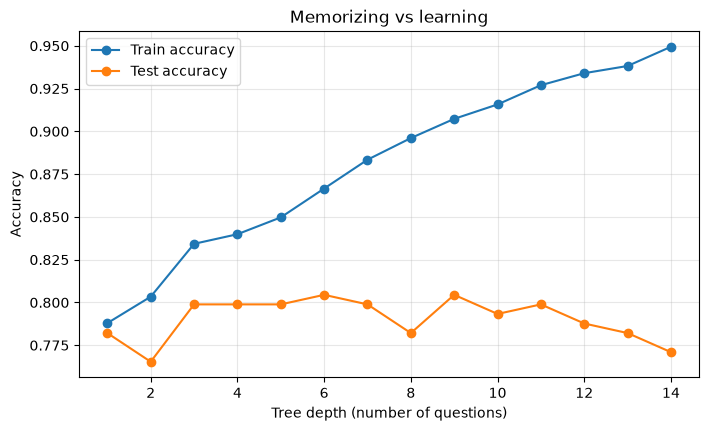

In [32]:
depths = range(1, 15)
train_acc, test_acc = [], []

for d in depths:
    t = DecisionTreeClassifier(max_depth=d, random_state=42).fit(X_train, y_train)
    train_acc.append(t.score(X_train, y_train))
    test_acc.append(t.score(X_test, y_test))

plt.figure(figsize=(8, 4.5))
plt.plot(depths, train_acc, marker="o", label="Train accuracy")
plt.plot(depths, test_acc, marker="o", label="Test accuracy")
plt.xlabel("Tree depth (number of questions)")
plt.ylabel("Accuracy")
plt.title("Memorizing vs learning")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

<div dir="rtl" style="text-align:right">

بفرما؛ معروف‌ترین تصویر یادگیری ماشین، رسم‌شده از داده خودمان. دقت آموزش تا نزدیک ۹۵٪ بالا می‌رود: درخت عمیق آن‌قدر سؤال می‌پرسد که عملا *تک‌تک مسافرها* را حفظ می‌کند. ولی دقت آزمون از جایی به بعد بهتر نمی‌شود و پس می‌رود. آن شکاف روبه‌رشد همان **بیش‌برازش (Overfitting)** است؛ دقیقا مفهوم جلسه‌های ۳ و ۴، این بار به چشم خودمان. این‌جا عمق ۳ تا ۵ نقطه طلایی است.

</div>

<div dir="rtl" style="text-align:right">

### ✏️ تمرین ۶
درختی با `max_depth=1` آموزش بده؛ یک «کنده» که فقط حق یک سؤال دارد؛ و دقت آزمونش را چاپ کن. با مدل تک‌قانونی ۶.۲ مقایسه کن. تعجب کردی؟

</div>

In [ ]:
# ✏️ نوبت توست
# stump = DecisionTreeClassifier(max_depth=..., random_state=42)

stump=DecisionTreeClassifier(max_depth=1,random_state=42)
stump.fit(X_train,y_train)
print('accuracy:',round(stump.score(X_test, y_test), 3))
#code by me

accuracy: 0.782


<div dir="rtl" style="text-align:right">

<details>
<summary>💡 راه‌حل (برای بازشدن کلیک کن)</summary>

<div dir="ltr" style="text-align:left">

```python
stump = DecisionTreeClassifier(max_depth=1, random_state=42)
stump.fit(X_train, y_train)
print("دقت کنده:", round(stump.score(X_test, y_test), 3))
```
</div>

دقیقا همان نمره قانون دست‌ساز جنسیت را می‌گیرد؛ چون وقتی فقط یک سؤال مجاز است، بهترین سؤال همین است: «این مسافر زن است؟». ماشین و شهود ما هم‌نظرند.

</details>

</div>

<div dir="rtl" style="text-align:right">

---
# بخش ۷: KNN: به همسایه‌هایت شبیهی

فلسفه‌ای کاملا متفاوت. **K نزدیک‌ترین همسایه (K-Nearest-Neighbors)** اصلا قانونی یاد نمی‌گیرد. برای پیش‌بینی یک مسافر جدید، فقط k مسافر *شبیه‌تر* به او را در داده آموزش پیدا می‌کند؛ «نزدیک‌ترین همسایه‌ها»؛ و می‌گذارد **رأی بدهند**. زنی ۲۵ ساله با بلیت درجه‌یک؟ ۵ مسافر شبیه‌تر را پیدا کن؛ اگر اکثرشان زنده ماندند، بگو «زنده می‌ماند».

«شبیه» یعنی *نزدیک* در تصویر بخش ۴.۵؛ فقط با هر ۹ ویژگی به‌جای ۲ تا.

</div>

<div dir="rtl" style="text-align:right">

### ۷.۱ تلاش اول

</div>

In [34]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

print("دقت:", round(knn.score(X_test, y_test), 3))

دقت: 0.715


<div dir="rtl" style="text-align:right">

**۷۱٪؟! بدتر از قانون یک‌خطی‌مان!** کجا خراب شد؟

به معنی «نزدیک» فکر کن. `Fare` از ۰ تا ۵۱۲ می‌رود، ولی `Female` فقط ۰ یا ۱ است. موقع محاسبه فاصله، اختلاف ۳۰ پوندی قیمت بلیت، تفاوت زن و مرد؛ مهم‌ترین ویژگی‌مان!؛ را کاملا غرق می‌کند. KNN شباهت را تقریبا فقط با قیمت بلیت می‌سنجید.

**راه‌حل:** اول همه ویژگی‌ها را هم‌مقیاس کن. `StandardScaler` دقیقا همین کار را می‌کند و `Pipeline` مقیاس‌گر و مدل را به هم زنجیر می‌کند تا مثل یک مدل واحد رفتار کنند (هر دو از جلسه قبل آشنایند).

</div>

<div dir="rtl" style="text-align:right">

### ۷.۲ تلاش دوم: اول هم‌مقیاس کن

</div>

In [35]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

knn_scaled = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5))
knn_scaled.fit(X_train, y_train)

acc = knn_scaled.score(X_test, y_test)
results["KNN (scaled)"] = acc
print("دقت:", round(acc, 3))

دقت: 0.804


<div dir="rtl" style="text-align:right">

از ۷۱٪ به ۸۰٪؛ **مدل عوض نشد، لباس داده عوض شد.** قاعده سرانگشتی: هر مدلی که بر پایه فاصله کار می‌کند (مثل KNN) ویژگی‌های هم‌مقیاس می‌خواهد. درخت‌ها اهمیتی نمی‌دهند، چون «سن ≤ ۶.۵؟» در هر مقیاسی همان سؤال است.

</div>

<div dir="rtl" style="text-align:right">

### ۷.۳ تماشای ذهن KNN
یک تصویر جایزه؛ نگران این کد نباش، از نتیجه لذت ببر. یک KNN کوچک را فقط روی دو ویژگی (سن و قیمت بلیت) آموزش می‌دهیم تا بتوانیم تصمیم‌هایش را نقاشی کنیم: هر نقطه صفحه به رنگ چیزی درمی‌آید که مدل آن‌جا پیش‌بینی *می‌کرد*.

</div>

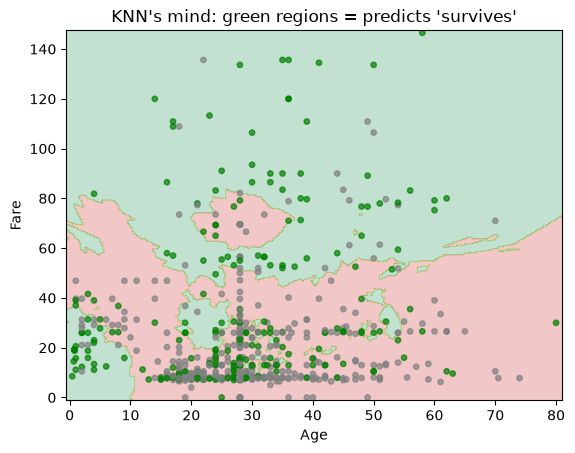

In [36]:
from sklearn.inspection import DecisionBoundaryDisplay

two_features = X_train[["Age", "Fare"]][X_train["Fare"] < 150]
two_labels = y_train[two_features.index]

knn_2d = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=15))
knn_2d.fit(two_features.values, two_labels)

display = DecisionBoundaryDisplay.from_estimator(
    knn_2d, two_features.values, response_method="predict",
    grid_resolution=300, alpha=0.25, cmap="RdYlGn")
display.ax_.scatter(two_features["Age"], two_features["Fare"],
                    c=two_labels.map({0: "gray", 1: "green"}), s=15, alpha=0.7)
plt.xlabel("Age")
plt.ylabel("Fare")
plt.title("KNN's mind: green regions = predicts 'survives'")
plt.show()

<div dir="rtl" style="text-align:right">

این جواب چالش بخش ۴.۵ است: مدل مرز را کشید؛ و هیچ خط راستی هم نیست. نقطه جدید هر جا بیفتد، رنگش را ناحیه‌ای که در آن افتاده تعیین می‌کند. جزیره‌های سبز دور خوشه‌های زنده‌مانده‌ها شکل گرفته‌اند: *به همسایه‌هایت شبیهی.*

</div>

<div dir="rtl" style="text-align:right">

### ۷.۴ انتخاب k: همان بده‌بستان قدیمی
`k` تعداد همسایه‌های رأی‌دهنده است. k کوچک: هر پیش‌بینی از روی یکی‌دو مسافر کپی می‌شود (حفظ‌کردن). k خیلی بزرگ: همه یک جواب می‌گیرند (ساده‌انگاری). آشنا نیست؟ همان قصه عمق درخت است؛ فقط برعکس.

</div>

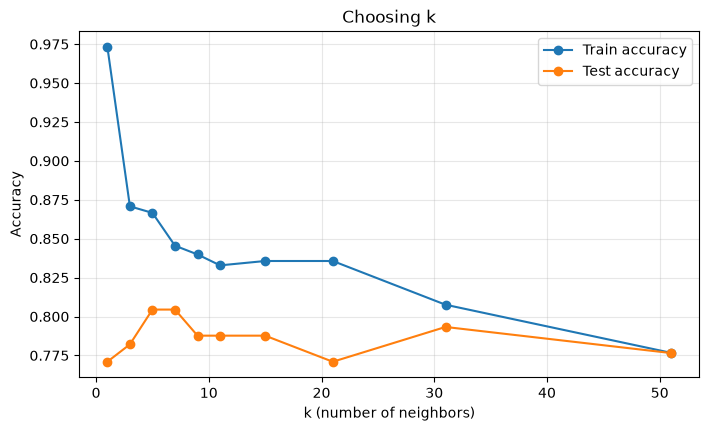

In [37]:
ks = [1, 3, 5, 7, 9, 11, 15, 21, 31, 51]
train_acc, test_acc = [], []

for k in ks:
    p = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k)).fit(X_train, y_train)
    train_acc.append(p.score(X_train, y_train))
    test_acc.append(p.score(X_test, y_test))

plt.figure(figsize=(8, 4.5))
plt.plot(ks, train_acc, marker="o", label="Train accuracy")
plt.plot(ks, test_acc, marker="o", label="Test accuracy")
plt.xlabel("k (number of neighbors)")
plt.ylabel("Accuracy")
plt.title("Choosing k")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

<div dir="rtl" style="text-align:right">

در `k=1` دقت آموزش ۹۶٪ خیره‌کننده است؛ معلوم است: نزدیک‌ترین همسایه هر مسافر آموزش، *خودش* است. حفظ‌کردن خالص، و نمره آزمون لوش می‌دهد. حوالی k = ۵ تا ۷ نمره آزمون به اوج می‌رسد. `k` و `max_depth` **ابرپارامتر (Hyperparameter)** هستند: پیچ‌هایی که *ما* تنظیم می‌کنیم و مدل خودش یاد نمی‌گیرد (واژگان جلسه ۳!).

یک هشدار: `k` را با نگاه‌کردن به نمره‌های *آزمون* انتخاب کردیم؛ اگر این کار را زیاد تکرار کنیم، مجموعه آزمون دیگر داور بی‌طرفی نیست. راه‌حل حرفه‌ای‌اش **اعتبارسنجی متقابل (Cross-Validation)** است (بخش ۹.۶).

</div>


<div dir="rtl" style="text-align:right">

### ✏️ تمرین ۷
برای *خودت* پیش‌بینی کن! مقدارهای زیر را با مشخصات خودت پر کن (درجه‌یک سفر می‌کردی یا درجه‌سه؟) و ببین KNN هم‌مقیاس‌شده برایت چه پیش‌بینی می‌کند.

</div>

In [ ]:
# ✏️ نوبت توست؛ مقدارها را با مشخصات خودت عوض کن
me = pd.DataFrame({
    "Pclass": [3],     # کلاس بلیتت: ۱ یا ۲ یا ۳
    "Female": [1],     # ۱ = زن، ۰ = مرد
    "Age": [28],       # سنت
    "SibSp": [0],      # خواهر/برادر/همسر همراه
    "Parch": [0],      # والدین/فرزندان همراه
    "Fare": [84],      # قیمت بلیت (درجه‌سه ≈ ۱۴، درجه‌دو ≈ ۲۱، درجه‌یک ≈ ۸۴ پوند)
    "Port_C": [0], "Port_Q": [0], "Port_S": [1],
})

print("پیش‌بینی:", knn_scaled.predict(me)[0], "  (۱ = زنده می‌ماند)")
#dead

پیش‌بینی: 0   (۱ = زنده می‌ماند)


<div dir="rtl" style="text-align:right">

<details>
<summary>💡 راه‌حل (برای بازشدن کلیک کن)</summary>

```python
print("پیش‌بینی:", knn_scaled.predict(me)[0], "  (۱ = زنده می‌ماند)")

# خود رأی‌گیری را هم می‌شود دید: احتمال تخمینی:
print("شانس زنده‌ماندن:", knn_scaled.predict_proba(me)[0][1])
```

`predict_proba` نتیجه رأی‌گیری را نشان می‌دهد: مثلا ۰.۴ یعنی ۲ نفر از ۵ همسایه زنده مانده‌اند.

</details>

</div>

<div dir="rtl" style="text-align:right">

---
# بخش ۸: جنگل تصادفی: خرد جمعی

یک درخت تنها مثل یک کارشناس تنهاست: باهوش، ولی یک‌دنده؛ داده آموزش را کمی تغییر بده و شاید درختی کاملا متفاوت بگیری. راه‌حل بیش از یک قرن قدمت دارد: سال ۱۹۰۶، فرانسیس گالتون آماردان در یک جشنواره روستایی دید که حدود ۸۰۰ نفر وزن یک گاو نر را حدس می‌زنند. تک‌تک حدس‌ها پرت‌وپلا بودند؛ ولی **میانگین‌شان کمتر از ۱٪ خطا داشت**.

**جنگل تصادفی (Random Forest)** = صدها درخت، که هر کدام روی نمونه‌ای تصادفی از مسافرها آموزش می‌بیند و در هر سؤالی که می‌پرسد فقط حق دارد به زیرمجموعه‌ای تصادفی از ویژگی‌ها نگاه کند (تا همه درخت‌ها از روی قوی‌ترین ویژگی کپی نکنند و عین هم نشوند؛ *اشتباه‌هایشان* مستقل بماند). برای پیش‌بینی: همه درخت‌ها رأی می‌دهند.

</div>

<div dir="rtl" style="text-align:right">

### ۸.۱ آموزش جنگل
`n_estimators` = تعداد درخت‌ها. هر درخت را کوچک نگه می‌داریم (`max_depth=5`)؛ بخش ۶ یادمان داد چرا.

</div>

In [41]:
from sklearn.ensemble import RandomForestClassifier

forest = RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42)
forest.fit(X_train, y_train)

acc = forest.score(X_test, y_test)
results["Random forest"] = acc
print("دقت:", round(acc, 3))

دقت: 0.816


In [ ]:
from sklearn.ensemble import RandomForestClassifier
forest= RandomForestClassifier(n_estimators=200,max_depth=5, random_state=42)
forest.fit(X_train, y_train)
acc=forest.score(X_test, y_test)
results['Random forest']=acc
print('accuracy:',round(acc,3))
#code by me

<div dir="rtl" style="text-align:right">

بهترین نمره‌مان تا این‌جا؛ جمعیت، تک‌تک کارشناس‌هایی را که امتحان کردیم شکست داد.

</div>

<div dir="rtl" style="text-align:right">

### ۸.۲ جنگل به چه چیزی اهمیت می‌دهد؟
۲۰۰ درخت را نمی‌شود کشید، ولی جنگل می‌تواند بگوید هر ویژگی چقدر در تصمیم‌هایش نقش داشته.

</div>

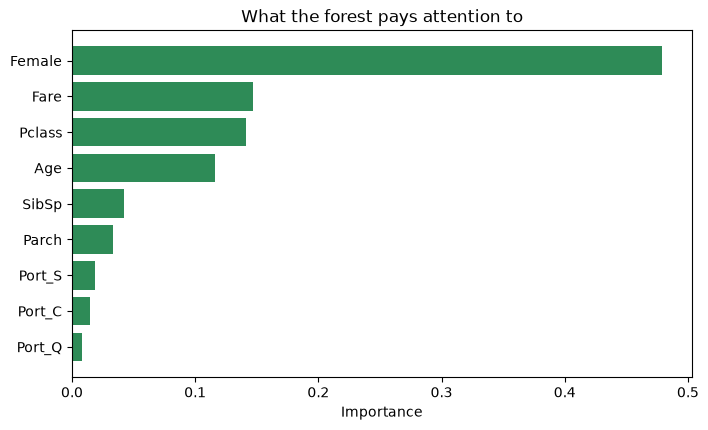

In [42]:
importances = pd.Series(forest.feature_importances_, index=FEATURES).sort_values()

plt.figure(figsize=(8, 4.5))
plt.barh(importances.index, importances.values, color="seagreen")
plt.xlabel("Importance")
plt.title("What the forest pays attention to")
plt.show()

<div dir="rtl" style="text-align:right">

جنسیت در صدر، بعد قیمت بلیت و سن؛ جنگل مستقلا همه حرف‌های نمودارهای بخش ۴ را تأیید می‌کند. این چرخه؛ *الگویی را در داده ببین، بعد بسنج که مدل هم پیدایش کرده*؛ راه اعتمادکردن به یک مدل است.

</div>

<div dir="rtl" style="text-align:right">

### ✏️ تمرین ۸
جمعیت بزرگ‌تر همیشه عاقل‌تر است؟ جنگل‌هایی با `n_estimators=5` و `n_estimators=500` آموزش بده و دقت آزمونشان را با جنگل ۲۰۰ درختی‌مان مقایسه کن.

</div>

In [ ]:
# ✏️ نوبت توست

forest=RandomForestClassifier(n_estimators=500, max_depth=5, random_state=42)
forest.fit(X_train,y_train)
acc=forest.score(X_test, y_test)
print('accuracy:',round(acc,3))
#code by me

accuracy: 0.816


In [45]:
for n in [5, 200, 500]:
    f=RandomForestClassifier(n_estimators=n, max_depth=5, random_state=42)
    f.fit(X_train, y_train)
    print(n,'tree',round(f.score(X_test, y_test),3))

5 tree 0.804
200 tree 0.816
500 tree 0.816


<div dir="rtl" style="text-align:right">

<details>
<summary>💡 راه‌حل (برای بازشدن کلیک کن)</summary>

```python
for n in [5, 200, 500]:
    f = RandomForestClassifier(n_estimators=n, max_depth=5, random_state=42)
    f.fit(X_train, y_train)
    print(n, "درخت:", round(f.score(X_test, y_test), 3))
```

۵ درخت کمی ضعیف‌تر است؛ از ۲۰۰ به ۵۰۰ هیچ‌چیز عوض نمی‌شود. خرد جمع اشباع می‌شود؛ از جایی به بعد، درخت بیشتر فقط وقت بیشتر می‌گیرد.

</details>

</div>

<div dir="rtl" style="text-align:right">

---
# بخش ۹: شیوه‌ی قهرمان‌ها: راه‌حلی برای صدر Kaggle

وقت قله است. اول یک هشدار صادقانه: در جدول امتیازات Kaggle نمره‌های ۱۰۰٪ می‌بینی. **تقلب است**؛ فهرست واقعی مسافران تایتانیک عمومی است و جواب‌ها را می‌شود از تاریخ پیدا کرد. راه‌حل‌های شرافتمندانه برتر حدود **۸۰ تا ۸۳٪** می‌گیرند، و راز واقعی‌شان این است:

> رازشان مدل عجیب‌وغریب‌تر *نیست*. **مهندسی ویژگی (Feature Engineering)** است؛ استفاده از بینش انسانی برای ساختن ویژگی‌های بهتر.

و این برای ما خبر فوق‌العاده‌ای است: یعنی راه قله دقیقا از مهارتی می‌گذرد که در بخش ۴ تمرین کردیم؛ *فهمیدن داده*. چهار ویژگی جدید می‌سازیم و بعد یک مدل نهایی می‌آوریم.

</div>

<div dir="rtl" style="text-align:right">

### ۹.۱ گنجی که در اسم‌ها پنهان است
تا حالا ستون `Name` را نادیده گرفته‌ایم. دقیق نگاه کن:

</div>

In [46]:
print(df["Name"].head(3).tolist())

['Braund, Mr. Owen Harris', 'Cumings, Mrs. John Bradley (Florence Briggs Thayer)', 'Heikkinen, Miss. Laina']


<div dir="rtl" style="text-align:right">

هر اسم یک **عنوان (Title)** دارد؛ کلمه بین ویرگول و نقطه: `Mr`، `Mrs`، `Miss`، `Master`… بیرونش می‌کشیم (`str.extract` دقیقا همان تکه وسط را برمی‌دارد)، چهار عنوان رایج را نگه می‌داریم و بقیه کمیاب‌ها (`Dr`، `Rev`، کنتس!…) را در گروه `"Rare"` می‌گذاریم.

</div>

In [47]:
data["Title"] = df["Name"].str.extract(r",\s*([^.]+)\.")[0].str.strip()
data["Title"] = data["Title"].replace(["Mlle", "Ms"], "Miss").replace("Mme", "Mrs")
data["Title"] = data["Title"].where(data["Title"].isin(["Mr", "Mrs", "Miss", "Master"]), "Rare")

print(data["Title"].value_counts())
print()
print("نرخ بقا بر حسب عنوان:")
print(data.groupby("Title")["Survived"].mean().round(2))

Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64

نرخ بقا بر حسب عنوان:
Title
Master    0.57
Miss      0.70
Mr        0.16
Mrs       0.79
Rare      0.35
Name: Survived, dtype: float64


<div dir="rtl" style="text-align:right">

چرا این طلاست؟ در سال ۱۹۱۲، **«Master» عنوان پسربچه‌ها بود**؛ پس این ویژگی به مدل می‌گوید بچه‌ها چه کسانی‌اند، *حتی وقتی سنشان جاافتاده*! و به نرخ‌های بقا نگاه کن: `Mr` ۱۶٪، `Master` ۵۸٪، `Mrs` ۷۹٪. یک کلمه‌ی بیرون‌کشیده، هم‌زمان جنسیت و سن و جایگاه اجتماعی را با خود حمل می‌کند.

</div>

<div dir="rtl" style="text-align:right">

### ۹.۲ اندازه خانواده
`SibSp` و `Parch` به‌تنهایی ویژگی‌های ضعیفی بودند (جنگل تقریبا سراغشان نمی‌رفت). ولی *جمعشان*؛ کل خانواده‌ای که با هم سفر می‌کنند؛ قصه‌ای برای گفتن دارد:

</div>

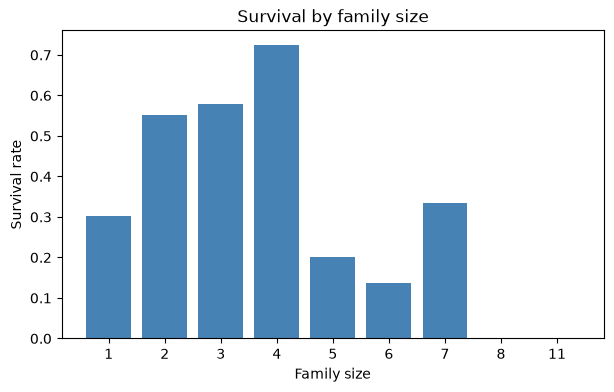

In [48]:
data["FamilySize"] = data["SibSp"] + data["Parch"] + 1     # +۱ یعنی خود مسافر
data["IsAlone"] = (data["FamilySize"] == 1).astype(int)

rate_by_family = data.groupby("FamilySize")["Survived"].mean()
plt.figure(figsize=(7, 4))
plt.bar(rate_by_family.index.astype(str), rate_by_family.values, color="steelblue")
plt.xlabel("Family size")
plt.ylabel("Survival rate")
plt.title("Survival by family size")
plt.show()

<div dir="rtl" style="text-align:right">

تنها سفرکردن: ۳۰٪. خانواده کوچک (۲ تا ۴ نفر): ۵۵ تا ۷۲٪؛ خانواده‌ها برای رسیدن به قایق‌ها به هم کمک می‌کردند و زن‌های بچه‌به‌بغل اولویت داشتند. خانواده بزرگ (۵ به بالا): نرخ سقوط می‌کند؛ خانواده‌های پرجمعیت بیشتر مسافران فقیر درجه‌سه بودند که موقع غرق‌شدن کشتی دنبال هم می‌گشتند. **دو ستون «به‌دردنخور»، با یک جمع ساده، تبدیل به قصه شدند.**

</div>

<div dir="rtl" style="text-align:right">

### ۹.۳ راه هوشمندانه‌تر برای سن‌های جاافتاده
در بخش ۵ همه سن‌های جاافتاده را با ۲۸ پر کردیم؛ حتی برای پسربچه‌های «Master»! حالا می‌توانیم بهترش کنیم: سن جاافتاده هر مسافر را با میانه *گروه عنوان خودش* پر کنیم.

</div>

In [49]:
print("میانه سن در هر عنوان:")
print(df.groupby(data["Title"])["Age"].median())

data["Age"] = df["Age"]                     # سن‌های اصلی را برمی‌گردانیم (با حفره‌ها)
data["Age"] = data.groupby("Title")["Age"].transform(lambda ages: ages.fillna(ages.median()))

print("\nسن‌های جاافتاده حالا:", data["Age"].isna().sum())

میانه سن در هر عنوان:
Title
Master     3.5
Miss      21.0
Mr        30.0
Mrs       35.0
Rare      48.5
Name: Age, dtype: float64

سن‌های جاافتاده حالا: 0


<div dir="rtl" style="text-align:right">

یک «Master» بدون سن، حالا به‌جای ۲۸، ۳.۵ سال می‌گیرد؛ یک بچه، همان‌طور که تقریبا به‌یقین بود. تمیزکاری با *بینش*، به‌جای یک قانون سراسری.

</div>

<div dir="rtl" style="text-align:right">

### ۹.۴ حتی حفره‌ها هم حرف دارند
`Cabin` را دور انداختیم چون ۷۷٪ خالی بود. ولی *همین‌که کابین کسی ثبت شده باشد یا نه* خودش حرف می‌زند:

</div>

In [50]:
data["HasCabin"] = df["Cabin"].notna().astype(int)

print(data.groupby("HasCabin")["Survived"].mean().round(2))

HasCabin
0    0.30
1    0.67
Name: Survived, dtype: float64


<div dir="rtl" style="text-align:right">

مسافرانی که کابین ثبت‌شده داشتند ۶۷٪ زنده ماندند در برابر ۳۰٪؛ کابین‌های ثبت‌شده بیشتر مال عرشه‌های بالایی بود. گاهی **خود جاافتادگی یک ویژگی است**.

</div>

<div dir="rtl" style="text-align:right">

### ۹.۵ مدل نهایی: گرادیان بوستینگ
جدول ویژگی‌های جدیدمان، به‌علاوه یک ایده آخر. جنگل تصادفی درخت‌هایش را *مستقل از هم* و موازی می‌سازد. **گرادیان بوستینگ (Gradient Boosting)** آن‌ها را *پشت سر هم* می‌سازد: هر درخت تازه مخصوصا روی **اشتباه‌های تیم تا این لحظه** آموزش می‌بیند و پیش‌بینی‌ها را یک قدم کوچک به سمت حقیقت هل می‌دهد.

آن «قدم کوچک به سمت خطای کمتر» باید زنگی به صدا درآورد؛ این همان **گرادیان کاهشی** است، نخ تسبیح این دوره، که حالا درخت می‌سازد. اندازه قدم حتی اسمش `learning_rate` است، دقیقا مثل جلسه ۴. این خانواده از مدل‌ها (و عموزاده‌های تنظیم‌شده‌اش XGBoost و LightGBM) در دنیای واقعی بیش از هر مدل دیگری مسابقه‌های داده جدولی را می‌برند.

</div>

In [51]:
data = pd.get_dummies(data, columns=["Title"], prefix="Title")

FEATURES_2 = ["Pclass", "Female", "Age", "SibSp", "Parch", "Fare",
              "Port_C", "Port_Q", "Port_S",
              "FamilySize", "IsAlone", "HasCabin",
              "Title_Mr", "Title_Mrs", "Title_Miss", "Title_Master", "Title_Rare"]

X2 = data[FEATURES_2]
y2 = data["Survived"]
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

from sklearn.ensemble import GradientBoostingClassifier
boost = GradientBoostingClassifier(random_state=42)
boost.fit(X2_train, y2_train)

acc = boost.score(X2_test, y2_test)
results["Boosting + features"] = acc
print("دقت:", round(acc, 3))

دقت: 0.844


<div dir="rtl" style="text-align:right">

**۸۴٪**؛ بهترین نمره‌مان، و شرافتمندانه. دقت کن که بیشتر این پیشرفت از *ویژگی‌ها* آمد، نه از مدل: همین بوستینگ روی ویژگی‌های قدیمی تقریبا هم‌رده جنگل نمره می‌گیرد.

</div>

<div dir="rtl" style="text-align:right">

### ۹.۶ مثل حرفه‌ای‌ها اندازه بگیر: اعتبارسنجی متقابل
یک تقسیم ۸۰/۲۰ یعنی نمره‌مان به این بستگی دارد که شانسی کدام ۱۷۹ مسافر در آزمون افتاده باشند؛ یعنی شانس. **اعتبارسنجی متقابل (Cross-Validation)** شانس را حذف می‌کند: داده را ۵ قسمت کن، ۵ بار آموزش بده، هر بار روی یک قسمت متفاوت آزمون بگیر و ۵ نمره را میانگین بگیر.

</div>

In [52]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(GradientBoostingClassifier(random_state=42), X2, y2, cv=5)

print("۵ نمره:", scores.round(3))
print("میانگین:", round(scores.mean(), 3), "±", round(scores.std(), 3))

۵ نمره: [0.827 0.82  0.848 0.815 0.854]
میانگین: 0.833 ± 0.016


<div dir="rtl" style="text-align:right">

حدود **۸۳٪ ± ۲٪**؛ تخمینی قابل‌اعتماد، درست وسط محدوده صدرنشین‌های شرافتمند Kaggle. هر وقت جدی خواستی مدل‌ها را مقایسه کنی، این عدد را به یک تقسیم تکی ترجیح بده.

</div>

<div dir="rtl" style="text-align:right">

### ۹.۷ کل جلسه در یک تصویر

</div>

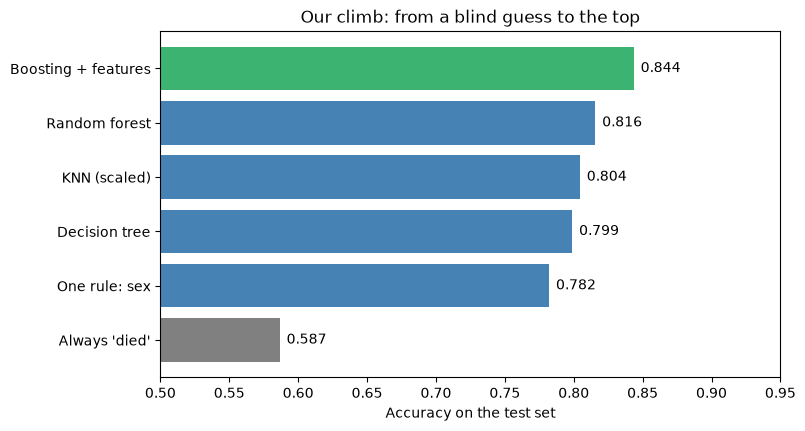

In [53]:
plt.figure(figsize=(8, 4.5))
names = list(results.keys())
scores = [results[n] for n in names]
colors = ["gray"] + ["steelblue"] * (len(names) - 2) + ["mediumseagreen"]

bars = plt.barh(names, scores, color=colors)
for bar, s in zip(bars, scores):
    plt.text(s + 0.005, bar.get_y() + bar.get_height() / 2, f"{s:.3f}", va="center")
plt.xlim(0.5, 0.95)
plt.xlabel("Accuracy on the test set")
plt.title("Our climb: from a blind guess to the top")
plt.show()

<div dir="rtl" style="text-align:right">

از ۵۹٪ تا ۸۴٪. ستون‌ها را از پایین به بالا بخوان و ببین جهش‌های بزرگ *از کجا* آمدند: یک بینش درباره جنسیت (‎+۱۹)، قانون‌هایی که ماشین یاد گرفت (‎+۲)، اصلاح مقیاس، خرد جمعی (‎+۲) و ویژگی‌های دست‌ساز انسان (‎+۳). **بینش بیشتر از هر الگوریتمی کار کرد.**

</div>

<div dir="rtl" style="text-align:right">

### ۹.۸ بلیت تو برای Kaggle 🎫
برای یک مسابقه واقعی آماده‌ای. در [kaggle.com/competitions/titanic](https://www.kaggle.com/competitions/titanic) دو فایل می‌گیری: `train.csv` (با جواب؛ همانی که امروز استفاده کردیم) و `test.csv` (۴۱۸ مسافر، با جواب‌های مخفی). روی اولی آموزش بده، برای دومی پیش‌بینی کن و یک فایل دوستونه آپلود کن:

```python
predictions = boost.predict(X_kaggle_test)
submission = pd.DataFrame({"PassengerId": test_ids, "Survived": predictions})
submission.to_csv("submission.csv", index=False)
```

Kaggle همان لحظه نمره‌ات را می‌دهد و در جدول امتیازات می‌نشاندت. با نوت‌بوک امروز باید نمره‌ای نزدیک ۰.۸۰ بگیری؛ بهتر از اکثر اولین‌ارسال‌های تاریخ این مسابقه. نمره‌های ۱.۰۰ را هم نادیده بگیر؛ حالا رازشان را می‌دانی.

</div>

<div dir="rtl" style="text-align:right">

### ✏️ تمرین ۹: چالش نهایی
‎۰.۴٪ مال خودت را دربیاور: ویژگی `FarePerPerson = Fare / FamilySize` را بساز (یک خانواده پول یک بلیت را قسمت می‌کنند!)، به `FEATURES_2` اضافه‌اش کن و اعتبارسنجی متقابل ۹.۶ را دوباره اجرا کن. میانگین بهتر شد؟

</div>

In [57]:
# ✏️ نوبت توست
# data["FarePerPerson"] = ...


data["FarePerPerson"] = data["Fare"] / data["FamilySize"]

X3 = data[FEATURES_2 + ["FarePerPerson"]]
scores = cross_val_score(GradientBoostingClassifier(random_state=42), X3, y2, cv=5)
print("میانگین:", round(scores.mean(), 3), "±", round(scores.std(), 3))


میانگین: 0.837 ± 0.017


<div dir="rtl" style="text-align:right">

<details>
<summary>💡 راه‌حل (برای بازشدن کلیک کن)</summary>
<div dir="ltr" style="text-align:left">

```python
data["FarePerPerson"] = data["Fare"] / data["FamilySize"]

X3 = data[FEATURES_2 + ["FarePerPerson"]]
scores = cross_val_score(GradientBoostingClassifier(random_state=42), X3, y2, cv=5)
print("میانگین:", round(scores.mean(), 3), "±", round(scores.std(), 3))
```
</div>
<div dir="rtl" style="text-align:right">
میانگین از حدود ۰.۸۳۲ به حدود ۰.۸۳۷ می‌رسد. کم است؛ ولی در جدول امتیازات Kaggle، نبردها دقیقا با همین قدم‌ها برده می‌شوند. حالا یک ویژگی از خودت اختراع کن!
</div>
</details>

</div>

<div dir="rtl" style="text-align:right">

---
# جمع‌بندی

امروز، روی یک مجموعه‌داده واقعی: دسته‌بندی چیست، خط پایه و **دقت**، قانون‌های دست‌ساز، **درخت تصمیم** (و خواندن ذهنش)، تماشای زنده بیش‌برازش، **KNN** و اهمیت هم‌مقیاس‌کردن، ابرپارامترها، **جنگل تصادفی** و اهمیت ویژگی‌ها، **مهندسی ویژگی** (عنوان‌ها، اندازه خانواده، جاافتادگی بامعنا)، **گرادیان بوستینگ** و **اعتبارسنجی متقابل**.

دو درس بالاتر از همه:

۱. **بینش از ماشین‌آلات مهم‌تر است.** هر جهش بزرگ جدول امتیازمان از فهمیدن آدم‌های یک کشتی در سال ۱۹۱۲ آمد.

۲. **به مدلی اعتماد کن که بشود ازش سؤال پرسید.** هر مدل را با الگوهایی سنجیدیم که چشم خودمان در بخش ۴ دیده بود.

تکلیفت: در Kaggle حساب باز کن، جواب بفرست و نمره‌ات را برایمان بنویس. جدول امتیازات را غرق کن! 🚢🎉

</div>